# EDA — Hotel Booking Cancellation

**Project:** Classical ML Pipeline  
**Dataset:** Hotel Booking Demand (Kaggle)  
**Target:** `is_canceled` (binary)  
**Author:** Sai  
**Started:** 2026-05-02

---

## Session 1 — Data Load & First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/hotel_bookings.csv')
print(f'Shape: {df.shape}')

Shape: (119390, 32)


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.00,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.10,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.40,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.00,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


## First Observations

*Write 5 sentences below describing what you see. No analysis yet — just what you notice.*

1. 
2. 
3. 
4. 
5. 

1. The data is for arrivals between 2015 through 2017
2. Some fields are booalean but the format is in int64
3. For all the bookings there are only 6797 hotels
4. The data seems more complete
5. Looks like some outliers in days waiting list

In [7]:
print(df['reservation_status'].value_counts())
print(df['hotel'].value_counts())

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
company,112593,94.30
agent,16340,13.70
country,488,0.40
children,4,0.00


In [9]:
print(df['is_canceled'].value_counts())
print(df['is_canceled'].value_counts(normalize=True).round(3))

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0   0.63
1   0.37
Name: proportion, dtype: float64


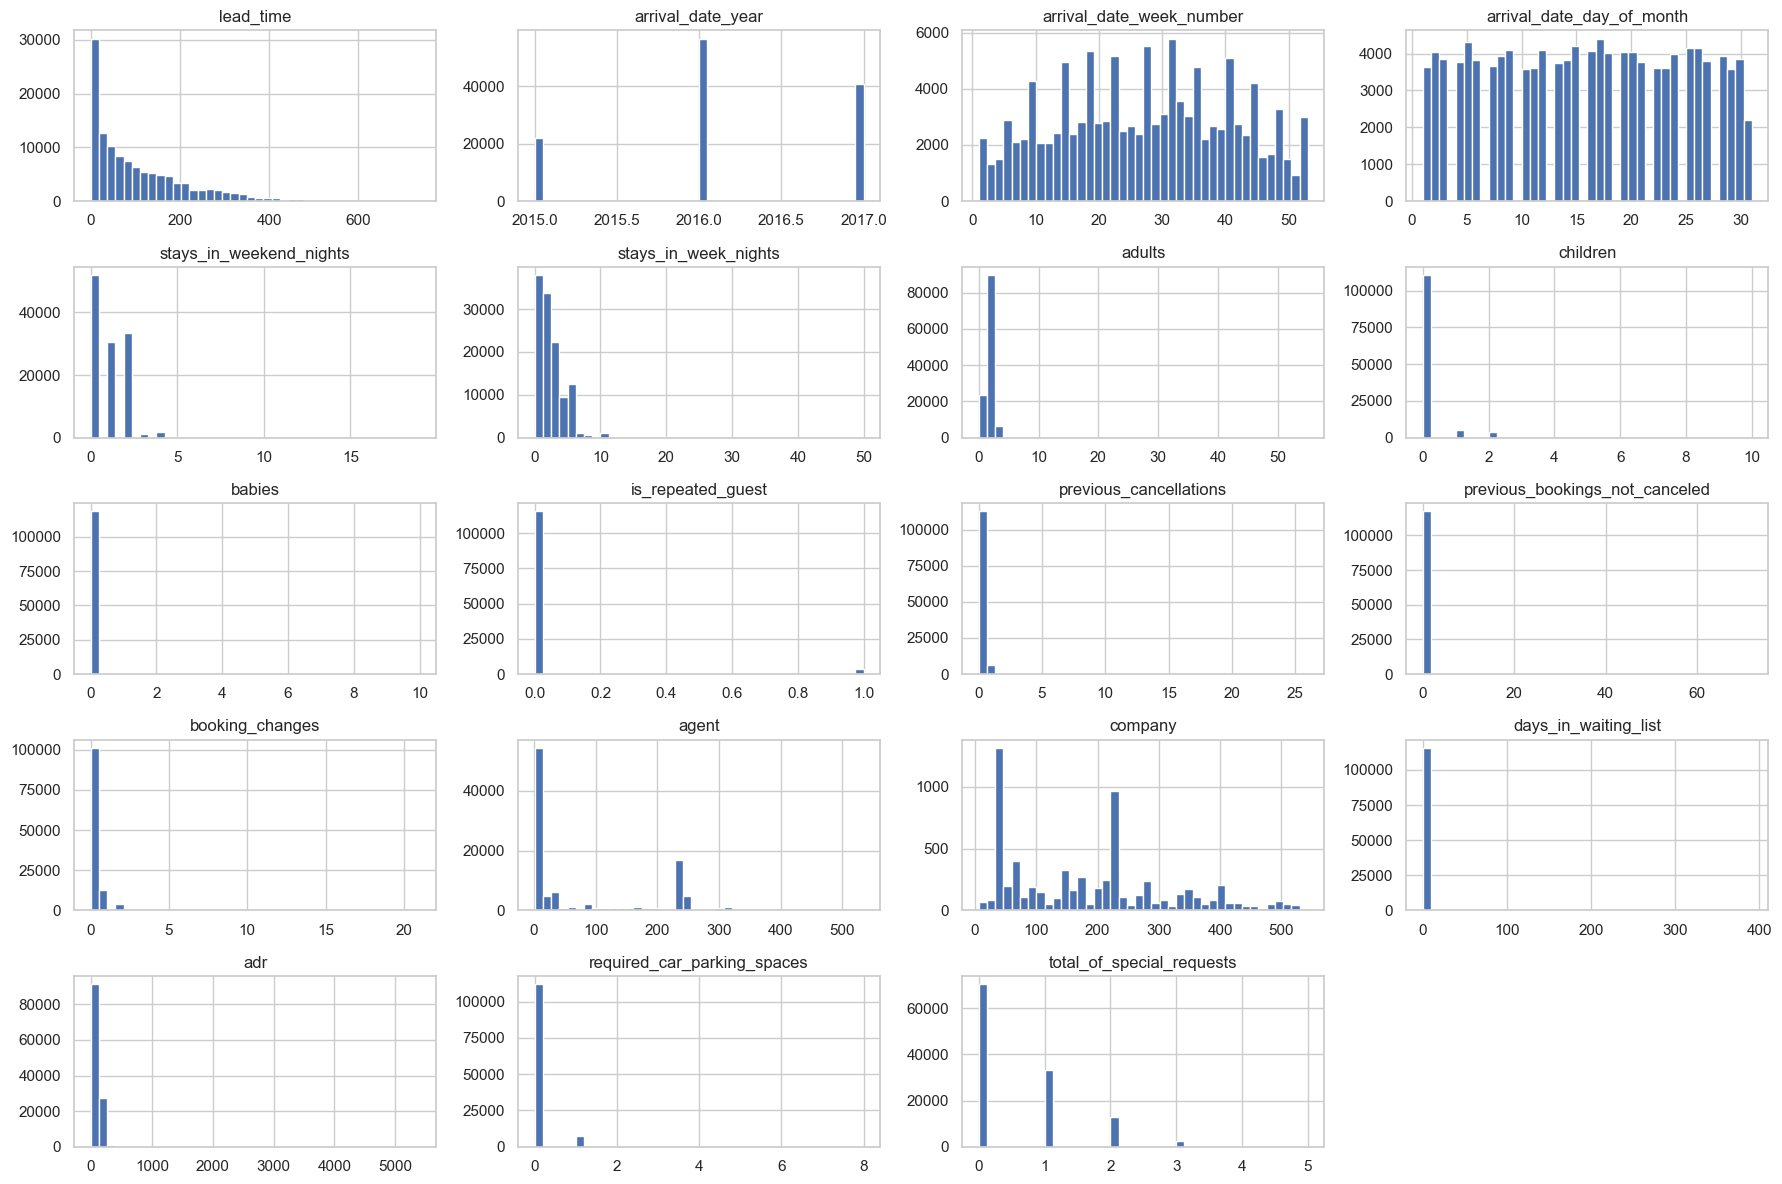

In [10]:
numeric_cols = df.select_dtypes(include='number').columns.drop('is_canceled')
df[numeric_cols].hist(figsize=(18, 12), bins=40)
plt.tight_layout()
plt.show()

/var/folders/j5/gkknqv694q7029z0449cbfgw0000gn/T/ipykernel_8863/1712322096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


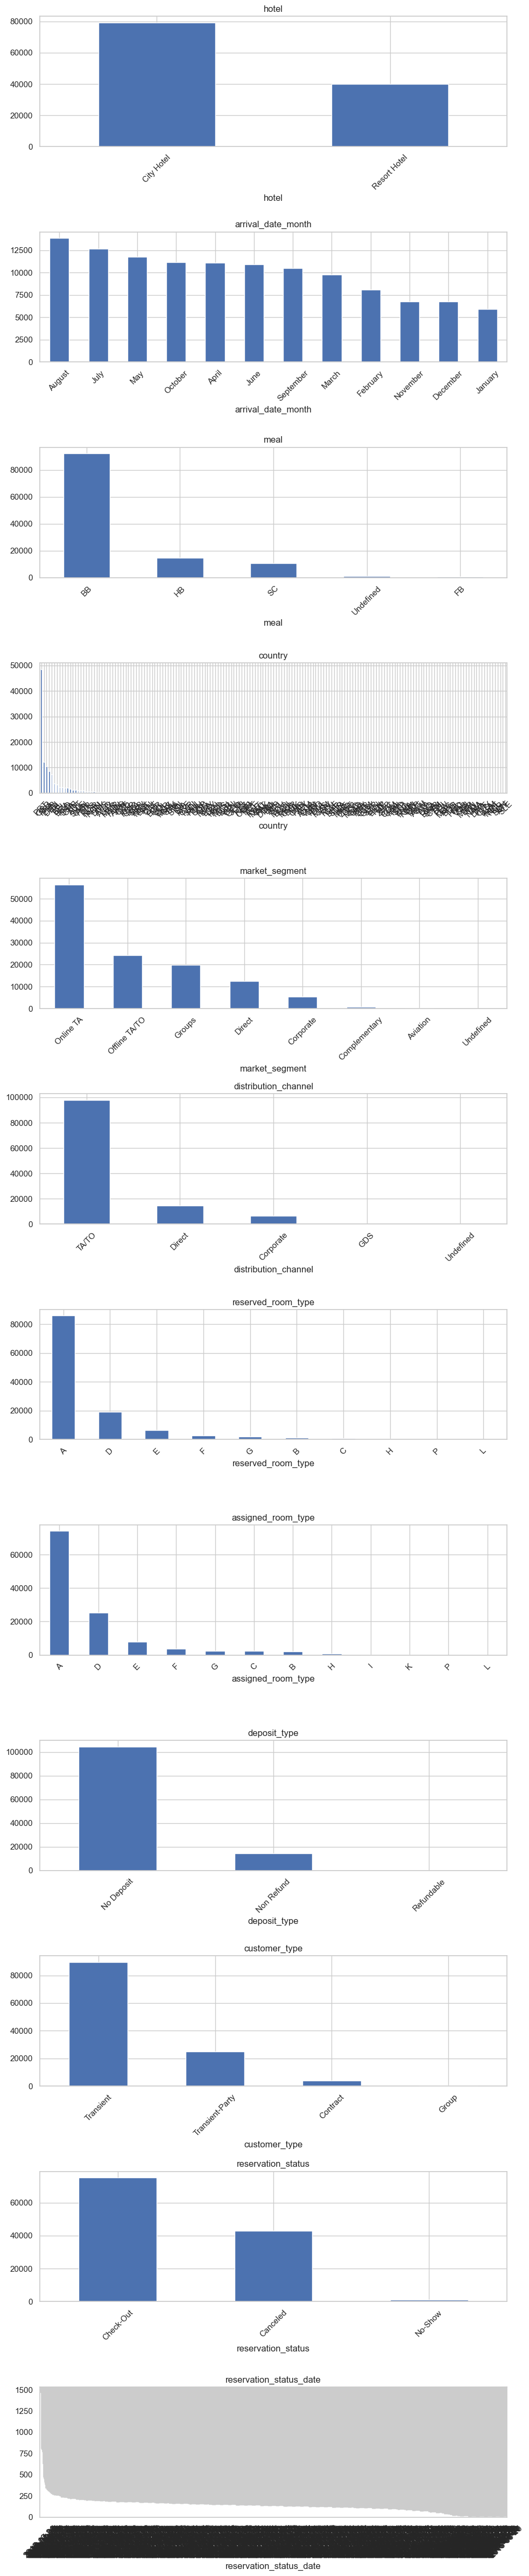

In [11]:
cat_cols = df.select_dtypes(include='object').columns
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print("adr negatives:", (df['adr'] < 0).sum())
print("lead_time > 365:", (df['lead_time'] > 365).sum())
print("adults == 0:", (df['adults'] == 0).sum())
print("stays both 0:", ((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)).sum())

adr negatives: 1
lead_time > 365: 3148
adults == 0: 403
stays both 0: 715


In [13]:
print("adr negatives:", (df['adr'] < 0).sum())
print("lead_time > 365:", (df['lead_time'] > 365).sum())  
print("adults == 0:", (df['adults'] == 0).sum())
print("stays both 0:", ((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)).sum())

adr negatives: 1
lead_time > 365: 3148
adults == 0: 403
stays both 0: 715


In [14]:
df[df['adults'] == 0][['adults', 'children', 'babies', 'is_canceled']].head(10)


,adults,children,babies,is_canceled
2224,0,0.00,0,0
2409,0,0.00,0,0
3181,0,0.00,0,0
3684,0,0.00,0,0
3708,0,0.00,0,0
4127,0,0.00,0,1
9376,0,0.00,0,1
31765,0,0.00,0,0
32029,0,0.00,0,0
32827,0,0.00,0,0


Session 2 Summary
The dataset covers 119,390 hotel bookings across two properties (Resort and City Hotel) from 2015–2017. 37% of bookings were cancelled, making accuracy a misleading metric. Four columns have missing values: company (94%) and agent (14%) are missing by design — those are direct bookings — and their missingness is itself a signal worth encoding as a feature. A handful of suspicious records exist: one negative ADR, 715 zero-night stays, and 403 adult-free bookings, all of which will be dropped or investigated before modeling. Two columns — deposit_type and distribution_channel — are heavily skewed toward a single value but may still carry signal in their minority categories.


In [15]:
## Session 3 — Bivariate Analysis

In [16]:
def cancellation_rate(df, col):
    return (df.groupby(col)['is_canceled']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'cancel_rate', 'count': 'n'})
              .sort_values('cancel_rate', ascending=False)
              .round(3))

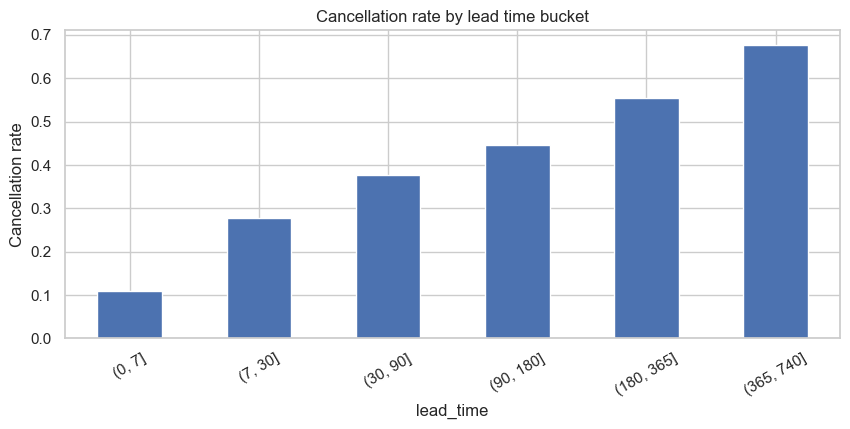

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(pd.cut(df['lead_time'], bins=[0,7,30,90,180,365,740]))['is_canceled'].mean().plot(kind='bar', ax=ax)
ax.set_title('Cancellation rate by lead time bucket')
ax.set_ylabel('Cancellation rate')
plt.xticks(rotation=30)
plt.show()

In [18]:
for col in ['hotel', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']:
    print(f"\n--- {col} ---")
    print(cancellation_rate(df, col))


--- hotel ---
              cancel_rate      n
hotel                           
City Hotel           0.42  79330
Resort Hotel         0.28  40060

--- market_segment ---
                cancel_rate      n
market_segment                    
Undefined              1.00      2
Groups                 0.61  19811
Online TA              0.37  56477
Offline TA/TO          0.34  24219
Aviation               0.22    237
Corporate              0.19   5295
Direct                 0.15  12606
Complementary          0.13    743

--- distribution_channel ---
                      cancel_rate      n
distribution_channel                    
Undefined                    0.80      5
TA/TO                        0.41  97870
Corporate                    0.22   6677
GDS                          0.19    193
Direct                       0.17  14645

--- deposit_type ---
              cancel_rate       n
deposit_type                     
Non Refund           0.99   14587
No Deposit           0.28  104641
Refu

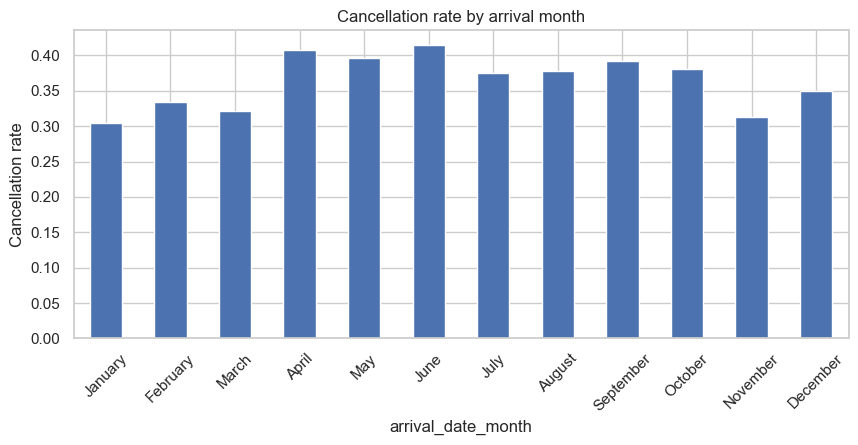

In [19]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
rates = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)
rates.plot(kind='bar', figsize=(10, 4), title='Cancellation rate by arrival month')
plt.ylabel('Cancellation rate')
plt.xticks(rotation=45)
plt.show()

In [20]:
for col in ['is_repeated_guest', 'previous_cancellations', 'total_of_special_requests']:
    print(f"\n--- {col} ---")
    print(cancellation_rate(df, col))


--- is_repeated_guest ---
                   cancel_rate       n
is_repeated_guest                     
0                         0.38  115580
1                         0.14    3810

--- previous_cancellations ---
                        cancel_rate       n
previous_cancellations                     
14                             1.00      14
19                             1.00      19
21                             1.00       1
24                             1.00      48
25                             1.00      25
26                             1.00      26
1                              0.94    6051
13                             0.92      12
0                              0.34  112906
2                              0.33     116
6                              0.32      22
3                              0.31      65
11                             0.29      35
4                              0.23      31
5                              0.10      19

--- total_of_special_requests ---
  

In [21]:
df['room_mismatch'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
print(cancellation_rate(df, 'room_mismatch'))

               cancel_rate       n
room_mismatch                     
0                     0.42  104473
1                     0.05   14917


In [22]:
# Columns to drop before modeling — and why
leakage_cols = [
    'reservation_status',       # directly encodes the outcome
    'reservation_status_date',  # set after cancellation
    'assigned_room_type',       # known only at check-in
]

print("Remaining columns after leakage drop:")
print([c for c in df.columns if c not in leakage_cols])


Remaining columns after leakage drop:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'room_mismatch']


Session #2 summary

identified and removed the leakage columns. 

In [23]:
# Drop leakage
leakage_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
df_clean = df.drop(columns=leakage_cols)

# Drop nonsense rows identified in Session 2
df_clean = df_clean[~((df_clean['stays_in_weekend_nights'] == 0) & 
                       (df_clean['stays_in_week_nights'] == 0))]
df_clean = df_clean[df_clean['adults'] > 0]
df_clean = df_clean[df_clean['adr'] >= 0]

print(f"Rows after cleaning: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

Rows after cleaning: 118341 (dropped 1049)


In [24]:
# Parse arrival date
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'] + '-' +
    df_clean['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

train = df_clean[df_clean['arrival_date'] < '2017-01-01']
val   = df_clean[(df_clean['arrival_date'] >= '2017-01-01') & 
                 (df_clean['arrival_date'] < '2017-09-01')]
test  = df_clean[df_clean['arrival_date'] >= '2017-09-01']

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Train cancel rate: {train['is_canceled'].mean():.3f}")
print(f"Val cancel rate:   {val['is_canceled'].mean():.3f}")
print(f"Test cancel rate:  {test['is_canceled'].mean():.3f}")

Train: 77895 | Val: 40446 | Test: 0
Train cancel rate: 0.365
Val cancel rate:   0.388
Test cancel rate:  nan


In [25]:
target = 'is_canceled'

# Start with a small set of clean numeric features — no encoding yet
baseline_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'total_of_special_requests'
]

X_train = train[baseline_features]
y_train = train[target]
X_val   = val[baseline_features]
y_val   = val[target]

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

print("=== Baseline: Majority Class ===")
print(classification_report(y_val, y_pred_dummy))
print(f"ROC AUC: {roc_auc_score(y_val, dummy.predict_proba(X_val)[:,1]):.3f}")

=== Baseline: Majority Class ===
              precision    recall  f1-score   support

           0       0.61      1.00      0.76     24747
           1       0.00      0.00      0.00     15699

    accuracy                           0.61     40446
   macro avg       0.31      0.50      0.38     40446
weighted avg       0.37      0.61      0.46     40446

ROC AUC: 0.500


/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_val)
y_prob_lr  = lr_baseline.predict_proba(X_val)[:,1]

print("=== Baseline: Logistic Regression ===")
print(classification_report(y_val, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_lr):.3f}")

=== Baseline: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.69      0.88      0.77     24747
           1       0.66      0.36      0.47     15699

    accuracy                           0.68     40446
   macro avg       0.67      0.62      0.62     40446
weighted avg       0.68      0.68      0.65     40446

ROC AUC: 0.730


In [28]:
# What's the ROC AUC?
print(f"Logistic Regression ROC AUC: {roc_auc_score(y_val, y_prob_lr):.3f}")

# What does the majority class baseline get?
print(f"Majority class ROC AUC: {roc_auc_score(y_val, dummy.predict_proba(X_val)[:,1]):.3f}")

Logistic Regression ROC AUC: 0.730
Majority class ROC AUC: 0.500


## Session 4 Summary
We split the data time-based (train: 2015–2016, val: early 2017, test: late 2017) to avoid future leakage into training. The majority class baseline scores 0.500 AUC — a coin flip. Logistic regression on numeric features only scores 0.730 AUC and catches only 36% of cancellations, giving us a clear floor to beat in Session 5 with proper feature engineering and categorical encoding.

In [29]:
df_model = df_clean.copy()

# Missing value signals — the absence IS the feature
df_model['is_corporate']      = df_model['company'].notnull().astype(int)
df_model['booked_via_agent']  = df_model['agent'].notnull().astype(int)

# Lead time buckets
df_model['lead_time_bucket'] = pd.cut(
    df_model['lead_time'],
    bins=[0, 7, 30, 90, 180, 365, 740],
    labels=['0-7d','1-4wk','1-3mo','3-6mo','6-12mo','12mo+']
).astype(str)

# Fill small missing values
df_model['children'] = df_model['children'].fillna(0)
df_model['country']  = df_model['country'].fillna('Unknown')

# Total guests
df_model['total_guests'] = df_model['adults'] + df_model['children'] + df_model['babies']

print(df_model[['is_corporate','booked_via_agent','lead_time_bucket','total_guests']].head())

   is_corporate  booked_via_agent lead_time_bucket  total_guests
2             0                 0             0-7d          1.00
3             0                 1            1-4wk          1.00
4             0                 1            1-4wk          2.00
5             0                 1            1-4wk          2.00
6             0                 0              NaN          2.00


In [30]:
numeric_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'total_guests', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list', 'adr',
    'total_of_special_requests', 'is_corporate', 'booked_via_agent'
]

categorical_features = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'deposit_type', 'customer_type', 'lead_time_bucket'
]

# Rebuild splits from df_model
train_m = df_model[df_model['arrival_date'] < '2017-01-01']
val_m   = df_model[(df_model['arrival_date'] >= '2017-01-01') & 
                   (df_model['arrival_date'] < '2017-09-01')]

X_train2 = train_m[numeric_features + categorical_features]
y_train2 = train_m['is_canceled']
X_val2   = val_m[numeric_features + categorical_features]
y_val2   = val_m['is_canceled']

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_full = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_full.fit(X_train2, y_train2)
y_pred  = lr_full.predict(X_val2)
y_prob  = lr_full.predict_proba(X_val2)[:,1]

print("=== Logistic Regression — Full Features ===")
print(classification_report(y_val2, y_pred))
print(f"ROC AUC: {roc_auc_score(y_val2, y_prob):.3f}")

=== Logistic Regression — Full Features ===
              precision    recall  f1-score   support

           0       0.80      0.78      0.79     24747
           1       0.67      0.69      0.68     15699

    accuracy                           0.75     40446
   macro avg       0.73      0.74      0.74     40446
weighted avg       0.75      0.75      0.75     40446

ROC AUC: 0.820


In [33]:
# Same pipeline, no class_weight — how much does recall drop?
lr_unweighted = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_unweighted.fit(X_train2, y_train2)
y_pred_uw = lr_unweighted.predict(X_val2)
y_prob_uw = lr_unweighted.predict_proba(X_val2)[:,1]

print(classification_report(y_val2, y_pred_uw))
print(f"ROC AUC: {roc_auc_score(y_val2, y_prob_uw):.3f}")

              precision    recall  f1-score   support

           0       0.75      0.91      0.82     24747
           1       0.79      0.52      0.63     15699

    accuracy                           0.76     40446
   macro avg       0.77      0.72      0.73     40446
weighted avg       0.77      0.76      0.75     40446

ROC AUC: 0.821


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {'lr__C': [0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(
    lr_full,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train2, y_train2)

print(f"Best C: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.3f}")

best_lr = grid_search.best_estimator_
y_prob_best = best_lr.predict_proba(X_val2)[:,1]
print(f"Val AUC: {roc_auc_score(y_val2, y_prob_best):.3f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C: {'lr__C': 10.0}
Best CV AUC: 0.843
Val AUC: 0.820


In [35]:
# Extract feature names after encoding
ohe_features = (best_lr.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_features))

all_features = numeric_features + list(ohe_features)
coefficients = best_lr.named_steps['lr'].coef_[0]

coef_df = (pd.DataFrame({'feature': all_features, 'coefficient': coefficients})
             .sort_values('coefficient', ascending=False))

print("=== Top 10 features pushing toward CANCELLATION ===")
print(coef_df.head(10).to_string(index=False))

print("\n=== Top 10 features pushing toward NOT CANCELLED ===")
print(coef_df.tail(10).to_string(index=False))

=== Top 10 features pushing toward CANCELLATION ===
                       feature  coefficient
       deposit_type_Non Refund         3.74
        previous_cancellations         3.03
                       meal_FB         0.73
        lead_time_bucket_12mo+         0.71
       lead_time_bucket_6-12mo         0.68
        lead_time_bucket_3-6mo         0.63
      market_segment_Online TA         0.57
       market_segment_Aviation         0.56
        lead_time_bucket_1-3mo         0.48
distribution_channel_Corporate         0.48

=== Top 10 features pushing toward NOT CANCELLED ===
                       feature  coefficient
         market_segment_Groups        -0.32
   distribution_channel_Direct        -0.33
     total_of_special_requests        -0.60
previous_bookings_not_canceled        -0.61
                meal_Undefined        -0.64
  market_segment_Offline TA/TO        -0.80
         lead_time_bucket_0-7d        -0.84
      lead_time_bucket_missing        -1.45
       deposit

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train2, y_train2)
y_prob_rf = rf.predict_proba(X_val2)[:,1]
y_pred_rf = rf.predict(X_val2)

print("=== Random Forest ===")
print(classification_report(y_val2, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_val2, y_prob_rf):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.76      0.88      0.81     24747
           1       0.74      0.56      0.64     15699

    accuracy                           0.75     40446
   macro avg       0.75      0.72      0.73     40446
weighted avg       0.75      0.75      0.75     40446

ROC AUC: 0.810


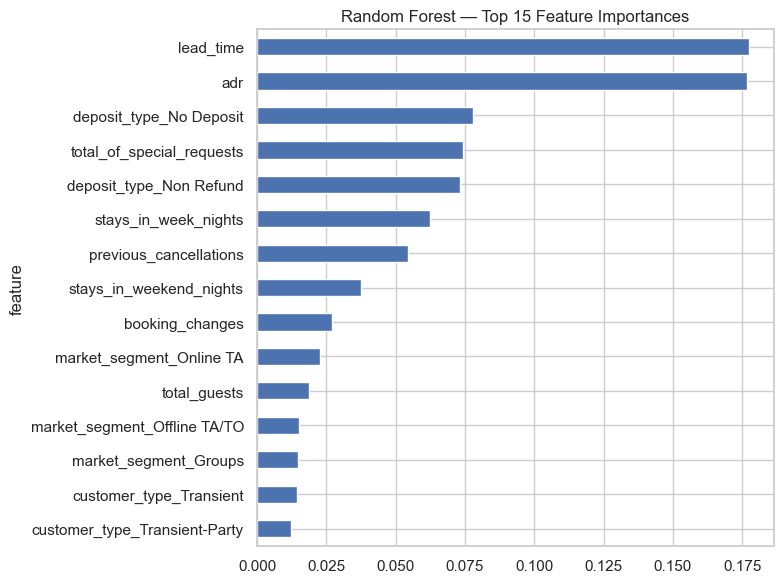

In [37]:
ohe_features = (rf.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_features))

all_features = numeric_features + list(ohe_features)
importances = rf.named_steps['rf'].feature_importances_

imp_df = (pd.DataFrame({'feature': all_features, 'importance': importances})
            .sort_values('importance', ascending=False)
            .head(15))

imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6), legend=False)
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train2 == 0).sum() / (y_train2 == 1).sum()

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train2, y_train2)
y_prob_xgb = xgb.predict_proba(X_val2)[:,1]
y_pred_xgb = xgb.predict(X_val2)

print("=== XGBoost ===")
print(classification_report(y_val2, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_val2, y_prob_xgb):.3f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.78      0.85      0.81     24747
           1       0.73      0.62      0.67     15699

    accuracy                           0.76     40446
   macro avg       0.75      0.74      0.74     40446
weighted avg       0.76      0.76      0.76     40446

ROC AUC: 0.835


In [39]:
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_val2, y_prob_xgb)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.3f}")
print(f"Precision at best: {precisions[best_idx]:.3f}")
print(f"Recall at best:    {recalls[best_idx]:.3f}")
print(f"F1 at best:        {f1_scores[best_idx]:.3f}")

Best threshold (max F1): 0.377
Precision at best: 0.618
Recall at best:    0.788
F1 at best:        0.693


predicting cancellation when guest actually shows up
this is more costly because customer is more troubled with this

In [40]:
y_pred_tuned = (y_prob_xgb >= best_threshold).astype(int)

print(f"\n=== XGBoost — Threshold {best_threshold:.3f} ===")
print(classification_report(y_val2, y_pred_tuned))
print(f"ROC AUC: {roc_auc_score(y_val2, y_prob_xgb):.3f}")


=== XGBoost — Threshold 0.377 ===
              precision    recall  f1-score   support

           0       0.84      0.69      0.76     24747
           1       0.62      0.79      0.69     15699

    accuracy                           0.73     40446
   macro avg       0.73      0.74      0.72     40446
weighted avg       0.75      0.73      0.73     40446

ROC AUC: 0.835


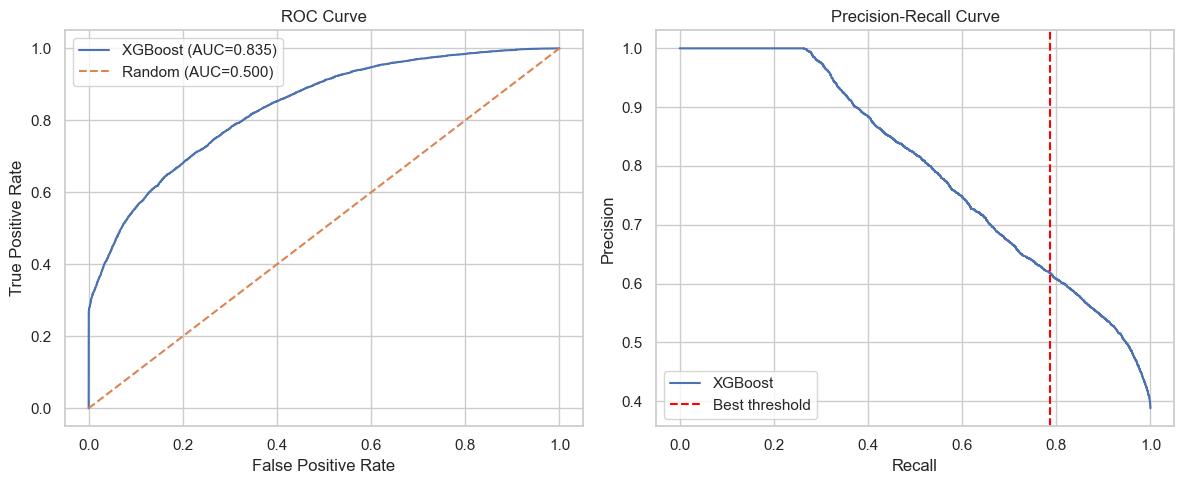

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_val2, y_prob_xgb)
axes[0].plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc_score(y_val2, y_prob_xgb):.3f})')
axes[0].plot([0,1],[0,1],'--', label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR curve
axes[1].plot(recalls, precisions, label='XGBoost')
axes[1].axvline(recalls[best_idx], color='red', linestyle='--', label=f'Best threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# # Rebuild test set
# test_m = df_model[df_model['arrival_date'] >= '2017-09-01']
# X_test = test_m[numeric_features + categorical_features]
# y_test = test_m['is_canceled']

# # Evaluate on test — one time, no going back
# y_prob_test = xgb.predict_proba(X_test)[:,1]
# y_pred_test = (y_prob_test >= best_threshold).astype(int)

# print("=== FINAL TEST SET EVALUATION ===")
# print(classification_report(y_test, y_pred_test))
# print(f"ROC AUC: {roc_auc_score(y_test, y_prob_test):.3f}")

In [43]:
print(df_model['arrival_date'].min(), df_model['arrival_date'].max())
print(df_model[df_model['arrival_date'].dt.year == 2017]['arrival_date_month'].value_counts())

2015-07-01 00:00:00 2017-08-31 00:00:00
arrival_date_month
May         6283
April       5635
June        5628
July        5283
March       4926
August      4912
February    4137
January     3642
Name: count, dtype: int64


In [44]:
train_m = df_model[df_model['arrival_date'] < '2017-01-01']
val_m   = df_model[(df_model['arrival_date'] >= '2017-01-01') & 
                   (df_model['arrival_date'] < '2017-06-01')]
test_m  = df_model[df_model['arrival_date'] >= '2017-06-01']

print(f"Train: {len(train_m)} | Val: {len(val_m)} | Test: {len(test_m)}")

Train: 77895 | Val: 24623 | Test: 15823


In [46]:
X_train2 = train_m[numeric_features + categorical_features]
y_train2 = train_m['is_canceled']
X_val2   = val_m[numeric_features + categorical_features]
y_val2   = val_m['is_canceled']
X_test   = test_m[numeric_features + categorical_features]
y_test   = test_m['is_canceled']

# Refit XGBoost on corrected train/val
xgb.fit(X_train2, y_train2)
y_prob_xgb = xgb.predict_proba(X_val2)[:,1]

# Redo threshold tuning on val
precisions, recalls, thresholds = precision_recall_curve(y_val2, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Best threshold: {best_threshold:.3f}")

# Final test eval
y_prob_test = xgb.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print("\n=== FINAL TEST SET EVALUATION ===")
print(classification_report(y_test, y_pred_test))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_test):.3f}")

Best threshold: 0.379

=== FINAL TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.82      0.63      0.71      9595
           1       0.58      0.79      0.67      6228

    accuracy                           0.69     15823
   macro avg       0.70      0.71      0.69     15823
weighted avg       0.73      0.69      0.69     15823

ROC AUC: 0.796
